## 0  Imports & Project Paths


In [1]:
import pathlib, time
import cv2
import numpy as np
import torch
import torchvision
import timm
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.transforms.functional import to_tensor
from torchvision import transforms

ROOT         = pathlib.Path(r"D:\เอกสาร\Connected")
VIDEO_IN     = ROOT / "entrance.mov"
DIR_FRAMES   = ROOT / "output" / "frames"
DIR_VIDEOS   = ROOT / "output" / "videos"
DIR_FEATURES = ROOT / "output" / "features"

for d in [DIR_FRAMES, DIR_VIDEOS, DIR_FEATURES]:
    d.mkdir(parents=True, exist_ok=True)

print("torch :", torch.__version__)
print("cuda  :", torch.cuda.is_available())


c:\Users\n.o_o.n\miniconda3\envs\ai6\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch : 2.6.0+cu124
cuda  : True


## 1  GPU Setup


In [2]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(DEVICE))
    print("VRAM   :", round(torch.cuda.get_device_properties(DEVICE).total_memory / 1024**3, 1), "GB")


device : cuda:0
GPU    : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM   : 4.0 GB


## 2  Step 1 — Head Point Detection

FasterRCNN-ResNet50-FPN-v2 (COCO pretrained) ทำหน้าที่ตรวจจับบุคคล
จากนั้น bounding box ถูกแปลงเป็น **head center point** (cx, cy)
แทน bounding box ตามแนวทาง PET (point-based localization)


In [3]:
PERSON_CLASS  = 1      # COCO label for "person"
SCORE_THRESH  = 0.9   # confidence threshold
BATCH_DETECT  = 4      # frames per detection batch

_weights  = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
detector  = fasterrcnn_resnet50_fpn_v2(weights=_weights).to(DEVICE)
detector.eval()
print("Detector  :", detector.__class__.__name__)
print("Backbone  : ResNet-50 + FPN v2 (COCO pretrained)")


Detector  : FasterRCNN
Backbone  : ResNet-50 + FPN v2 (COCO pretrained)


In [4]:
def bbox_to_head_point(box):
    """Convert [x1,y1,x2,y2] bbox to head center (cx, cy).
    Head is approximated at 12% from the top of the body box.
    """
    x1, y1, x2, y2 = box
    cx = (x1 + x2) / 2
    cy = y1 + (y2 - y1) * 0.12
    return float(cx), float(cy)


def detect_heads(frames_rgb: list[np.ndarray]) -> list[dict]:
    """
    Run detector on a batch of RGB frames.
    Returns list of dicts: {points: [(cx,cy),...], scores: [...]}
    """
    tensors = [to_tensor(f).to(DEVICE) for f in frames_rgb]
    with torch.no_grad():
        preds = detector(tensors)

    results = []
    for pred in preds:
        mask   = (pred["labels"] == PERSON_CLASS) & (pred["scores"] > SCORE_THRESH)
        boxes  = pred["boxes"][mask].cpu().numpy()
        scores = pred["scores"][mask].cpu().numpy().tolist()
        points = [bbox_to_head_point(b) for b in boxes]
        results.append({"points": points, "scores": scores})
    return results


## 3  Step 2 — Appearance Descriptor Extraction (ConvNext-S)

ConvNext-S ทำหน้าที่เป็น **backbone** สกัด descriptor 768-dim จาก patch รอบศีรษะ
Patch ถูกตัดขนาด `PATCH_SIZE × PATCH_SIZE` px โดยมีศูนย์กลางที่ head point


In [5]:
PATCH_SIZE     = 128   # pixels — crop size centered at head point
CONVNEXT_INPUT = 224   # ConvNext-S expected input size

convnext = timm.create_model("convnext_small", pretrained=True, num_classes=0)
convnext = convnext.to(DEVICE)
convnext.eval()

with torch.no_grad():
    _out = convnext(torch.zeros(1, 3, CONVNEXT_INPUT, CONVNEXT_INPUT, device=DEVICE))
DESCRIPTOR_DIM = _out.shape[-1]

print("Backbone   :", "ConvNext-S (ImageNet pretrained, head removed)")
print("Descriptor :", DESCRIPTOR_DIM, "dim")
print("Patch size :", PATCH_SIZE, "x", PATCH_SIZE, "px  ->  resize", CONVNEXT_INPUT, "x", CONVNEXT_INPUT)


Backbone   : ConvNext-S (ImageNet pretrained, head removed)
Descriptor : 768 dim
Patch size : 128 x 128 px  ->  resize 224 x 224


In [6]:
_patch_resize = transforms.Resize((CONVNEXT_INPUT, CONVNEXT_INPUT), antialias=True)
_patch_norm   = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225],
)


def extract_patch(frame_rgb: np.ndarray, cx: int, cy: int) -> np.ndarray:
    """Crop PATCH_SIZE x PATCH_SIZE around (cx, cy). Edge-pad if out of bounds."""
    H, W  = frame_rgb.shape[:2]
    half  = PATCH_SIZE // 2
    x1, y1, x2, y2 = cx - half, cy - half, cx + half, cy + half
    pl = max(0, -x1);  pr = max(0, x2 - W)
    pt = max(0, -y1);  pb = max(0, y2 - H)
    crop = frame_rgb[max(0, y1):min(H, y2), max(0, x1):min(W, x2)]
    if pl or pr or pt or pb:
        crop = np.pad(crop, ((pt, pb), (pl, pr), (0, 0)), mode="edge")
    return crop  # (PATCH_SIZE, PATCH_SIZE, 3) uint8


def patches_to_descriptors(patches: list[np.ndarray]) -> torch.Tensor:
    """
    patches : list of (H, W, 3) uint8 numpy arrays
    returns : (N, DESCRIPTOR_DIM) float32 tensor on DEVICE
    """
    if not patches:
        return torch.zeros(0, DESCRIPTOR_DIM, device=DEVICE)
    tensors = [
        _patch_norm(_patch_resize(torch.from_numpy(p).permute(2, 0, 1).float() / 255.0))
        for p in patches
    ]
    batch = torch.stack(tensors).to(DEVICE)
    with torch.no_grad():
        return convnext(batch)  # (N, 768)


## 4  Full Pipeline — Process All Frames & Save

รัน Step 1 + Step 2 บนทุก frame ใน `entrance.mov`
บันทึกผลลัพธ์เป็น `output/features/descriptors_all_frames.pt`

```python
{
    frame_idx: {
        "points": [(cx, cy), ...],     # head center points
        "scores": [float, ...],        # detection confidence
        "descs" : Tensor(N, 768),      # ConvNext-S descriptors (CPU)
    }
}
```


In [7]:
OUT_PT = DIR_FEATURES / "descriptors_all_frames.pt"

cap   = cv2.VideoCapture(str(VIDEO_IN))
fps   = cap.get(cv2.CAP_PROP_FPS)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Video :", VIDEO_IN.name, "|", total, "frames @", round(fps, 1), "fps")

all_data: dict[int, dict] = {}
buf: list[tuple[int, np.ndarray]] = []   # (frame_idx, frame_rgb)
t0 = time.perf_counter()


def flush(buf):
    idxs  = [b[0] for b in buf]
    rgbs  = [b[1] for b in buf]
    dets  = detect_heads(rgbs)
    for fi, rgb, det in zip(idxs, rgbs, dets):
        patches = [extract_patch(rgb, int(cx), int(cy)) for cx, cy in det["points"]]
        descs   = patches_to_descriptors(patches).cpu()
        all_data[fi] = {
            "points": det["points"],
            "scores": det["scores"],
            "descs" : descs,
        }


frame_idx = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    buf.append((frame_idx, cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)))
    if len(buf) == BATCH_DETECT:
        flush(buf)
        buf.clear()
    frame_idx += 1
    if frame_idx % 500 == 0:
        elapsed = time.perf_counter() - t0
        eta     = elapsed / frame_idx * (total - frame_idx)
        pct     = frame_idx / total * 100
        print(f"  {frame_idx}/{total} ({pct:.0f}%)  ETA {eta:.0f}s")

if buf:
    flush(buf)

cap.release()
torch.save(all_data, OUT_PT)

elapsed  = time.perf_counter() - t0
size_mb  = OUT_PT.stat().st_size / 1024**2
n_people = sum(len(v["points"]) for v in all_data.values())
print(f"Done in {elapsed:.0f}s")
print(f"Saved  : {OUT_PT.name}  ({size_mb:.1f} MB)")
print(f"Frames : {len(all_data)}")
print(f"Persons detected (total): {n_people}")
print(f"Avg persons / frame     : {n_people / len(all_data):.1f}")


Video : entrance.mov | 2556 frames @ 29.9 fps
  500/2556 (20%)  ETA 551s
  1000/2556 (39%)  ETA 413s
  1500/2556 (59%)  ETA 288s
  2000/2556 (78%)  ETA 154s
  2500/2556 (98%)  ETA 16s
Done in 720s
Saved  : descriptors_all_frames.pt  (53.8 MB)
Frames : 2548
Persons detected (total): 17933
Avg persons / frame     : 7.0


## 5  Verify Saved File


In [9]:
data = torch.load(OUT_PT, weights_only=False)

sample_key  = sorted(data.keys())[len(data)//2]   # middle frame
sample      = data[sample_key]

print("Keys in file :", len(data), "frames")
print("Sample frame :", sample_key)
print("  persons    :", len(sample["points"]))
print("  scores     :", [round(s, 2) for s in sample["scores"]])
print("  descs shape:", sample["descs"].shape)
print("  descs dtype:", sample["descs"].dtype)


Keys in file : 2548 frames
Sample frame : 1274
  persons    : 9
  scores     : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.97, 0.91]
  descs shape: torch.Size([9, 768])
  descs dtype: torch.float32


## 6  Step 3 — ICG (Implicit Context Generator)

**เป้าหมาย:** สร้าง context-enriched descriptor ด้วย dot-product self-attention ระหว่างบุคคลในเฟรมเดียวกัน

**Attention Map 4 ส่วน:**

| ตำแหน่ง | คำอธิบาย |
|---|---|
| Q1 ซ้าย-บน | Intra-frame: Raw cosine similarity (เปรียบ descriptor ดิบในเฟรมเดียวกัน) |
| Q2 ขวา-บน | Intra-frame: ICG attention weights (หลัง self-attention) |
| Q3 ซ้าย-ล่าง | Cross-frame: Raw cosine similarity กับเฟรมก่อนหน้า |
| Q4 ขวา-ล่าง | Cross-frame: ICG-enhanced cosine similarity (context descriptor) |


In [26]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ICG_TEMPERATURE = 1.0  # scales softmax; lower = sharper attention


def icg_attention(descs: torch.Tensor):
    """
    Implicit Context Generator: scaled dot-product self-attention.
    descs : (N, D) raw descriptors (float32, any device)
    Returns
        ctx  : (N, D) context-enriched descriptors, L2-normalised
        attn : (N, N) row-softmax attention weight matrix
    """
    if descs.shape[0] == 0:
        return descs, torch.zeros(0, 0, device=descs.device)

    d     = F.normalize(descs.float(), dim=-1)          # (N, D)
    scale = d.shape[-1] ** 0.5 * ICG_TEMPERATURE
    sim   = d @ d.T / scale                             # (N, N)
    attn  = F.softmax(sim, dim=-1)                      # row-softmax
    ctx   = F.normalize(attn @ descs.float(), dim=-1)   # (N, D)
    return ctx, attn


print("ICG function ready  (temperature =", ICG_TEMPERATURE, ")")


ICG function ready  (temperature = 1.0 )


In [27]:
OUT_ICG_PT = DIR_FEATURES / "icg_all_frames.pt"

raw_data = torch.load(OUT_PT, weights_only=False)

icg_data: dict[int, dict] = {}
for fi, frame_info in raw_data.items():
    descs = frame_info["descs"].to(DEVICE)
    ctx, attn = icg_attention(descs)
    icg_data[fi] = {
        "points": frame_info["points"],
        "scores": frame_info["scores"],
        "descs" : frame_info["descs"],
        "ctx"   : ctx.cpu(),
        "attn"  : attn.cpu(),
    }

torch.save(icg_data, OUT_ICG_PT)
size_mb = OUT_ICG_PT.stat().st_size / 1024**2
print(f"ICG applied to {len(icg_data)} frames")
print(f"Saved: {OUT_ICG_PT.name}  ({size_mb:.1f} MB)")

sample_fi = sorted(icg_data.keys())[len(icg_data)//2]
sf = icg_data[sample_fi]
N  = len(sf["points"])
print(f"\nSample frame {sample_fi}: {N} persons")
print(f"  raw descs : {sf['descs'].shape}")
print(f"  ctx descs : {sf['ctx'].shape}")
print(f"  attn      : {sf['attn'].shape}")
d_raw = F.normalize(sf["descs"].float(), dim=-1)
avg_raw = (d_raw @ d_raw.T).mean().item()
avg_ctx = (sf["ctx"].float() @ sf["ctx"].float().T).mean().item()
print(f"  avg intra cosine (raw): {avg_raw:.3f}")
print(f"  avg intra cosine (ICG): {avg_ctx:.3f}")


ICG applied to 2548 frames
Saved: icg_all_frames.pt  (108.2 MB)

Sample frame 1274: 9 persons
  raw descs : torch.Size([9, 768])
  ctx descs : torch.Size([9, 768])
  attn      : torch.Size([9, 9])
  avg intra cosine (raw): 0.531
  avg intra cosine (ICG): 1.000


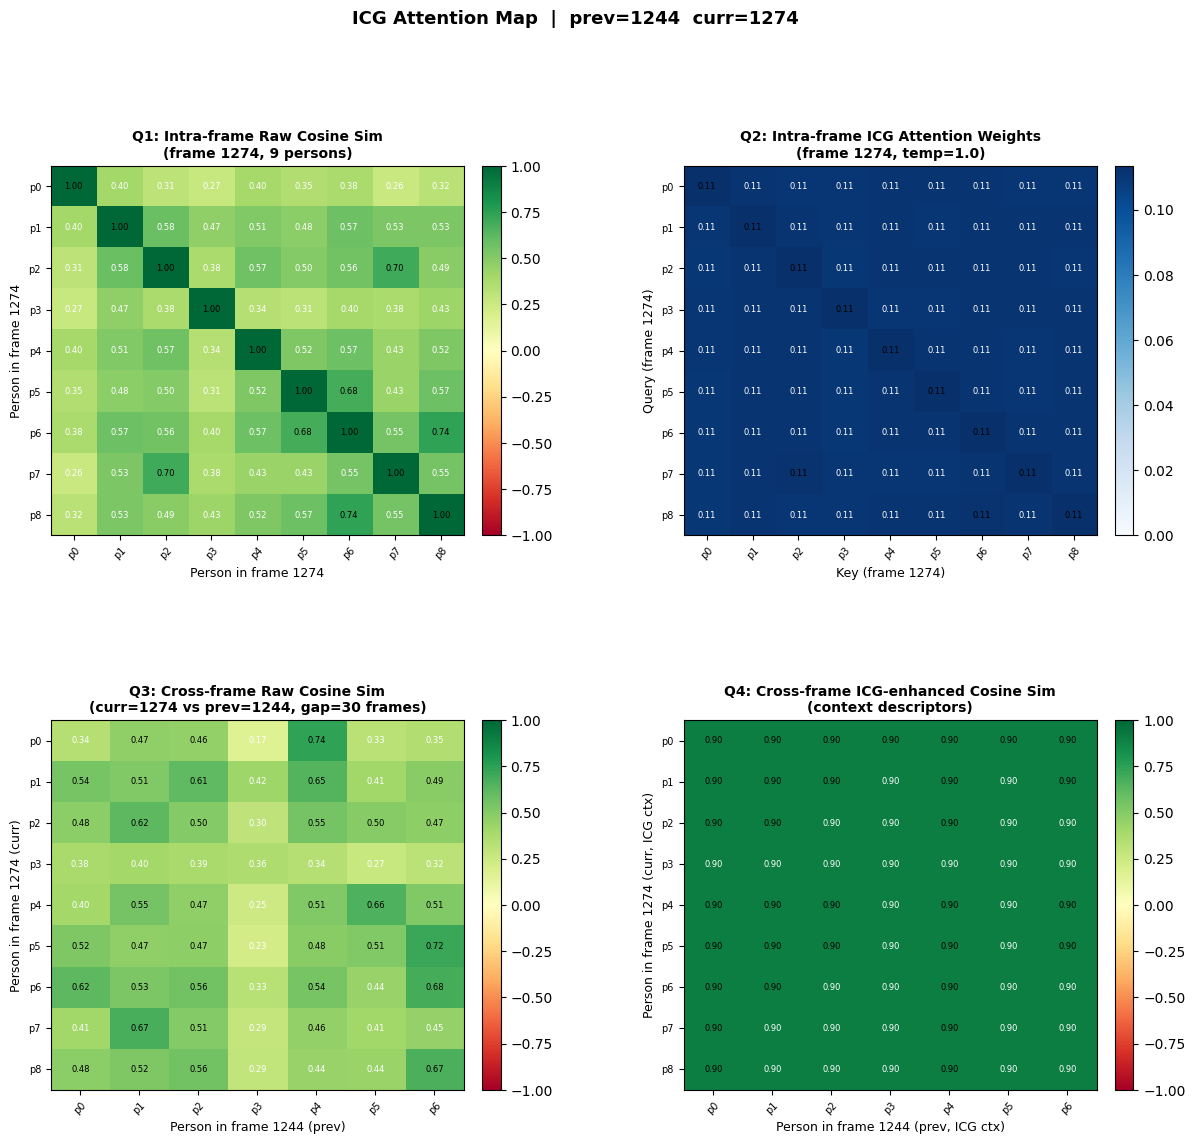

Saved: D:\เอกสาร\Connected\output\frames\icg_attention_map.png

Top ICG-enhanced cross-frame matches (frame 1274 -> 1244):
  curr-p00 (1218,373) -> prev-p00  ICG=0.905  raw=0.341
  curr-p01 (1467,367) -> prev-p00  ICG=0.904  raw=0.545
  curr-p02 (876,322) -> prev-p00  ICG=0.904  raw=0.481
  curr-p03 (1767,311) -> prev-p00  ICG=0.904  raw=0.384
  curr-p04 (990,321) -> prev-p00  ICG=0.904  raw=0.404
  curr-p05 (615,319) -> prev-p00  ICG=0.904  raw=0.518
  curr-p06 (676,301) -> prev-p00  ICG=0.904  raw=0.621
  curr-p07 (869,236) -> prev-p00  ICG=0.904  raw=0.413
  curr-p08 (717,270) -> prev-p00  ICG=0.904  raw=0.480


In [29]:
VIS_FRAME_GAP = 30

all_keys = sorted(icg_data.keys())
mid_idx  = len(all_keys) // 2
fi_curr  = all_keys[mid_idx]
fi_prev  = all_keys[max(0, mid_idx - VIS_FRAME_GAP)]

curr = icg_data[fi_curr]
prev = icg_data[fi_prev]
N_curr = len(curr["points"])
N_prev = len(prev["points"])

# Q1: Intra-frame raw cosine similarity
d_curr_raw = F.normalize(curr["descs"].float(), dim=-1)
Q1 = (d_curr_raw @ d_curr_raw.T).numpy()

# Q2: Intra-frame ICG attention weights
Q2 = curr["attn"].numpy()

# Q3: Cross-frame raw cosine similarity
d_prev_raw = F.normalize(prev["descs"].float(), dim=-1)
Q3 = (d_curr_raw @ d_prev_raw.T).numpy()

# Q4: Cross-frame ICG-enhanced cosine similarity
Q4 = (curr["ctx"].float() @ prev["ctx"].float().T).numpy()


def annotate_heatmap(ax, mat, xlabel, ylabel, title, vmin=None, vmax=None, cmap="viridis"):
    im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    nr, nc = mat.shape
    ax.set_xticks(range(nc)); ax.set_xticklabels([f"p{j}" for j in range(nc)], fontsize=7, rotation=45)
    ax.set_yticks(range(nr)); ax.set_yticklabels([f"p{i}" for i in range(nr)], fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fs = 6 if max(nr, nc) > 8 else 7
    mid = (mat.max() + mat.min()) / 2
    for r in range(nr):
        for c in range(nc):
            ax.text(c, r, f"{mat[r,c]:.2f}", ha="center", va="center",
                    fontsize=fs, color="white" if mat[r,c] < mid else "black")


fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.40)

ax1 = fig.add_subplot(gs[0, 0])
annotate_heatmap(ax1, Q1,
    xlabel=f"Person in frame {fi_curr}",
    ylabel=f"Person in frame {fi_curr}",
    title=f"Q1: Intra-frame Raw Cosine Sim\n(frame {fi_curr}, {N_curr} persons)",
    vmin=-1, vmax=1, cmap="RdYlGn")

ax2 = fig.add_subplot(gs[0, 1])
annotate_heatmap(ax2, Q2,
    xlabel=f"Key (frame {fi_curr})",
    ylabel=f"Query (frame {fi_curr})",
    title=f"Q2: Intra-frame ICG Attention Weights\n(frame {fi_curr}, temp={ICG_TEMPERATURE})",
    vmin=0, vmax=Q2.max(), cmap="Blues")

ax3 = fig.add_subplot(gs[1, 0])
annotate_heatmap(ax3, Q3,
    xlabel=f"Person in frame {fi_prev} (prev)",
    ylabel=f"Person in frame {fi_curr} (curr)",
    title=f"Q3: Cross-frame Raw Cosine Sim\n(curr={fi_curr} vs prev={fi_prev}, gap={fi_curr - fi_prev} frames)",
    vmin=-1, vmax=1, cmap="RdYlGn")

ax4 = fig.add_subplot(gs[1, 1])
annotate_heatmap(ax4, Q4,
    xlabel=f"Person in frame {fi_prev} (prev, ICG ctx)",
    ylabel=f"Person in frame {fi_curr} (curr, ICG ctx)",
    title=f"Q4: Cross-frame ICG-enhanced Cosine Sim\n(context descriptors)",
    vmin=-1, vmax=1, cmap="RdYlGn")

fig.suptitle(
    f"ICG Attention Map  |  prev={fi_prev}  curr={fi_curr}",
    fontsize=13, fontweight="bold", y=1.01
)
out_png = DIR_FRAMES / "icg_attention_map.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

# Top cross-frame matches
print(f"\nTop ICG-enhanced cross-frame matches (frame {fi_curr} -> {fi_prev}):")
for i in range(N_curr):
    best_j = int(Q4[i].argmax())
    score  = Q4[i, best_j]
    raw_sc = Q3[i, best_j] if best_j < N_prev else float('nan')
    px, py = curr["points"][i]
    print(f"  curr-p{i:02d} ({int(px)},{int(py)}) -> prev-p{best_j:02d}  "
          f"ICG={score:.3f}  raw={raw_sc:.3f}")


In [30]:
# Cross-frame consistency scan: sequential frames
# ยิ่ง avg_best_ICG สูง = คนในเฟรมต่อเนื่องกันมีลักษณะตรงกัน

SCAN_FRAMES = 10
HIGH_CONF_THR = 0.70

scan_keys = all_keys[mid_idx - SCAN_FRAMES // 2 : mid_idx + SCAN_FRAMES // 2 + 1]
print(f"Sequential scan: frames {scan_keys[0]} .. {scan_keys[-1]}")
print(f"{'Frame pair':>20}  {'curr':>5}  {'prev':>5}  {'avg_best_ICG':>13}  {'high_conf(>{HIGH_CONF_THR})':>16}")
print('-' * 75)

for i in range(1, len(scan_keys)):
    fi_c = scan_keys[i]
    fi_p = scan_keys[i - 1]
    c = icg_data[fi_c]
    p = icg_data[fi_p]
    if not c["points"] or not p["points"]:
        continue
    sim = (c["ctx"].float() @ p["ctx"].float().T)  # (N_c, N_p)
    best = sim.max(dim=1).values
    avg_best  = best.mean().item()
    high_conf = (best > HIGH_CONF_THR).sum().item()
    pair = f"{fi_p} -> {fi_c}"
    print(f"  {pair:>18}  {len(c['points']):>5}  {len(p['points']):>5}  "
          f"{avg_best:>13.3f}  {high_conf:>16}")


Sequential scan: frames 1269 .. 1279
          Frame pair   curr   prev   avg_best_ICG  high_conf(>{HIGH_CONF_THR})
---------------------------------------------------------------------------
        1269 -> 1270      7      8          0.936                 7
        1270 -> 1271      7      7          0.928                 7
        1271 -> 1272      7      7          0.938                 7
        1272 -> 1273      8      7          0.936                 8
        1273 -> 1274      9      8          0.963                 9
        1274 -> 1275      9      9          0.965                 9
        1275 -> 1276      9      9          0.967                 9
        1276 -> 1277      9      9          0.964                 9
        1277 -> 1278      9      9          0.949                 9
        1278 -> 1279     10      9          0.957                10


## 7  Step 3 — ICG Video Output

สร้างวิดีโอ 2 ช่อง:
- **ซ้าย (1280x720):** frame เดิม + วาด ICG overlay
  - วงกลมที่หัว: สี **เขียว** = ICG cross-frame match สูง (น่าจะคนเดิม), **แดง** = ต่ำ (คนใหม่/หาย)
  - เส้นระหว่างคน: ICG intra-frame attention สูง = เส้นสว่าง/หนา
  - label: `p{i} >j(score)` = p{i} ตรงกับ prev-p{j} ด้วย score
- **ขวา (640x720):** attention heatmap 2 ส่วน
  - Q2 (บน): Intra-frame ICG attention weights
  - Q4 (ล่าง): Cross-frame ICG-enhanced similarity กับ frame ก่อนหน้า


In [31]:
VID_ICG_OUT    = DIR_VIDEOS / "icg_output.mp4"
MAIN_W, MAIN_H = 1280, 720
PANEL_W        = 640
OUT_W, OUT_H   = MAIN_W + PANEL_W, MAIN_H
ATTN_TOP_K     = 3      # max attention edges per person
ATTN_MIN_W     = 0.12   # min attention weight to draw edge
SIGMA_PX       = 40     # spatial Gaussian sigma (px); ~2x per-frame movement (~20px at 30fps walking speed)
ALPHA_SPATIAL  = 0.5    # blend weight: 0=pure ICG appearance, 1=pure spatial
NEW_PERSON_THR = 0.35   # combined score below this -> treated as new person

cap_r   = cv2.VideoCapture(str(VIDEO_IN))
fps_in  = cap_r.get(cv2.CAP_PROP_FPS)
total_r = int(cap_r.get(cv2.CAP_PROP_FRAME_COUNT))
sx      = MAIN_W / cap_r.get(cv2.CAP_PROP_FRAME_WIDTH)
sy      = MAIN_H / cap_r.get(cv2.CAP_PROP_FRAME_HEIGHT)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(VID_ICG_OUT), fourcc, fps_in, (OUT_W, OUT_H))


def mat_to_bgr(mat_f32, cmap, lo=0.0, hi=1.0):
    norm = np.clip((mat_f32 - lo) / max(hi - lo, 1e-8), 0, 1)
    return cv2.applyColorMap((norm * 255).astype(np.uint8), cmap)


t0 = time.perf_counter()
prev_fi = None
fi = 0

while cap_r.isOpened():
    ret, bgr = cap_r.read()
    if not ret:
        break

    main  = cv2.resize(bgr, (MAIN_W, MAIN_H))
    panel = np.full((OUT_H, PANEL_W, 3), 20, dtype=np.uint8)

    if fi in icg_data:
        d    = icg_data[fi]
        N    = len(d['points'])
        attn = d['attn'].numpy() if N > 0 else np.zeros((0, 0), dtype=np.float32)

        # --- Cross-frame: ICG appearance + spatial position joint score ---
        sim_mat    = None   # combined score matrix (N_curr x N_prev), range [0, 1]
        cross_best = np.full(N, 0.5)
        if prev_fi is not None and N > 0 and len(icg_data[prev_fi]['points']) > 0:
            # Raw descriptors: more discriminative than ctx (ctx collapses to mean when uniforms match)
            raw_c = F.normalize(d['descs'].float(), dim=-1)                        # (N_c, D)
            raw_p = F.normalize(icg_data[prev_fi]['descs'].float(), dim=-1)        # (N_p, D)
            sim_raw = (raw_c @ raw_p.T).numpy()               # (N_c, N_p) in [-1, 1]

            # Spatial Gaussian: high when positions are close between frames
            pos_c = np.array(d['points'], dtype=np.float32)                  # (N_c, 2)
            pos_p = np.array(icg_data[prev_fi]['points'], dtype=np.float32)  # (N_p, 2)
            dists = np.sqrt(((pos_c[:, None] - pos_p[None])**2).sum(-1))     # (N_c, N_p)
            spatial = np.exp(-dists**2 / (2 * SIGMA_PX**2))                  # [0, 1]

            # Blend: normalize raw sim from [-1,1] -> [0,1] then mix with spatial
            raw_norm = (sim_raw + 1) / 2
            sim_mat  = (1 - ALPHA_SPATIAL) * raw_norm + ALPHA_SPATIAL * spatial
            cross_best = sim_mat.max(axis=1)   # [0, 1]

        # Intra-frame attention edges
        for i in range(N):
            if attn.shape[0] == 0:
                break
            row = attn[i].copy()
            row[i] = 0
            for j in np.argsort(row)[-ATTN_TOP_K:]:
                w = float(row[j])
                if w < ATTN_MIN_W:
                    continue
                p1 = (int(d['points'][i][0] * sx), int(d['points'][i][1] * sy))
                p2 = (int(d['points'][j][0] * sx), int(d['points'][j][1] * sy))
                intensity = int(min(255, w * 800))
                cv2.line(main, p1, p2, (0, intensity, intensity),
                         max(1, int(w * 8)), cv2.LINE_AA)

        # Person circles + labels
        for i in range(N):
            px = int(d['points'][i][0] * sx)
            py = int(d['points'][i][1] * sy)
            cs = float(cross_best[i])           # 0=new/lost, 1=same person
            is_new = cs < NEW_PERSON_THR

            # Color: green=same, yellow=uncertain, red=new/lost
            circ_color = (0, int(cs * 255), int((1 - cs) * 255))  # BGR
            radius = 10
            cv2.circle(main, (px, py), radius, circ_color, -1)
            cv2.circle(main, (px, py), radius, (255, 255, 255), 1)
            if is_new:
                cv2.circle(main, (px, py), radius + 4, (0, 0, 255), 2)  # red ring = new

            cv2.putText(main, f'p{i}', (px + 13, py - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
            if sim_mat is not None:
                best_j = int(sim_mat[i].argmax())
                tag = 'NEW' if is_new else f'>{best_j}({cs:.2f})'
                tag_color = (0, 50, 255) if is_new else (200, 200, 200)
                cv2.putText(main, tag, (px + 13, py + 12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.38, tag_color, 1, cv2.LINE_AA)

        # HUD
        cv2.putText(main, f'Frame {fi:4d}  persons: {N}',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2, cv2.LINE_AA)
        cv2.putText(main, f'green=match  red=new/lost  thr={NEW_PERSON_THR}  spatial={ALPHA_SPATIAL}',
                    (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1)
        cv2.putText(main, f'sigma_px={SIGMA_PX}  lines=ICG intra-frame attn',
                    (10, 73), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1)

        # Panel top: Q2 intra-frame attention heatmap
        half = OUT_H // 2
        cv2.putText(panel, 'Q2: Intra-frame ICG Attention',
                    (8, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (220, 220, 220), 1)
        if N > 0 and attn.shape[0] > 0:
            hw   = half - 50
            hmap = mat_to_bgr(attn, cv2.COLORMAP_INFERNO, 0.0, max(float(attn.max()), 1e-8))
            hmap = cv2.resize(hmap, (hw, hw))
            panel[30:30 + hw, 10:10 + hw] = hmap

        # Panel bottom: combined score heatmap (Q4 enhanced)
        lbl_prev = str(prev_fi) if prev_fi is not None else 'N/A'
        cv2.putText(panel, f'Q4: Raw desc+Spatial combined (vs {lbl_prev})',
                    (8, half + 22), cv2.FONT_HERSHEY_SIMPLEX, 0.43, (220, 220, 220), 1)
        if sim_mat is not None:
            h2 = half - 50
            w2 = min(PANEL_W - 20, int(h2 * sim_mat.shape[1] / max(sim_mat.shape[0], 1)))
            hmap2 = mat_to_bgr(sim_mat, cv2.COLORMAP_TURBO, 0.0, 1.0)
            hmap2 = cv2.resize(hmap2, (w2, h2))
            panel[half + 30: half + 30 + h2, 10:10 + w2] = hmap2

        prev_fi = fi

    # Compose & write
    canvas = np.zeros((OUT_H, OUT_W, 3), dtype=np.uint8)
    canvas[:, :MAIN_W] = main
    canvas[:, MAIN_W:] = panel
    cv2.line(canvas, (MAIN_W, 0), (MAIN_W, OUT_H), (80, 80, 80), 2)
    writer.write(canvas)

    fi += 1
    if fi % 500 == 0:
        elapsed = time.perf_counter() - t0
        eta     = elapsed / fi * (total_r - fi)
        print(f'  {fi}/{total_r} ({fi / total_r * 100:.0f}%)  ETA {eta:.0f}s')

cap_r.release()
writer.release()

elapsed = time.perf_counter() - t0
size_mb = VID_ICG_OUT.stat().st_size / 1024**2
print(f'Done in {elapsed:.0f}s')
print(f'Saved: {VID_ICG_OUT}  ({size_mb:.1f} MB)')


  500/2556 (20%)  ETA 53s
  1000/2556 (39%)  ETA 38s
  1500/2556 (59%)  ETA 26s
  2000/2556 (78%)  ETA 13s
  2500/2556 (98%)  ETA 1s
Done in 62s
Saved: D:\เอกสาร\Connected\output\videos\icg_output.mp4  (176.0 MB)


## 8  Step 4 — DPI (Displacement Prior Injector)

**เป้าหมาย:** assign track ID แต่ละคนตลอดวิดีโอ โดยรวม 2 signal:

| Signal | สูตร | บทบาท |
|---|---|---|
| Appearance | cosine(raw_desc_i, raw_desc_j) | คนหน้าตาเหมือนกันไหม |
| Displacement Prior | Gaussian(pos_j, center=pred_i, σ) | คนอยู่ตรงที่คาดไหม |

**Displacement Prior** ใช้ constant-velocity model:
`pred(T+1) = pos(T) + (pos(T) - pos(T-1))`
คนที่ตรงตำแหน่งที่ทำนายไว้ได้รับ score สูงขึ้น

**Hungarian matching** (scipy) จับคู่ทีละ frame แบบ optimal one-to-one


In [32]:
from collections import deque
from scipy.optimize import linear_sum_assignment
import torch.nn.functional as F

# ---- DPI parameters ----
DPI_SIGMA     = 60    # Gaussian sigma around predicted position (original-res px)
DPI_ALPHA     = 0.45  # 0=appearance only, 1=displacement prior only
DPI_MATCH_THR = 0.30  # min combined score to accept a match
DPI_MAX_LOST  = 30    # frames before lost track is deleted
DESC_EMA_BETA = 0.80  # EMA weight for descriptor update (higher=trust history more)


class Track:
    _next_id = 0

    def __init__(self, pos, desc, frame_idx):
        self.tid      = Track._next_id
        Track._next_id += 1
        self.pos_hist = deque([(frame_idx, pos)], maxlen=3)
        self.desc_ema = F.normalize(desc.float(), dim=0)
        self.lost_age = 0
        self.age      = 1

    @property
    def last_pos(self):
        return self.pos_hist[-1][1]

    def predict_pos(self, target_fi):
        """Constant-velocity prediction to target_fi."""
        if len(self.pos_hist) < 2:
            return self.last_pos
        (fi1, p1), (fi2, p2) = self.pos_hist[-2], self.pos_hist[-1]
        dt = target_fi - fi2
        vx = (p2[0] - p1[0]) / max(fi2 - fi1, 1)
        vy = (p2[1] - p1[1]) / max(fi2 - fi1, 1)
        return (p2[0] + vx * dt, p2[1] + vy * dt)

    def update(self, pos, desc, frame_idx):
        self.pos_hist.append((frame_idx, pos))
        new_d = F.normalize(desc.float(), dim=0)
        self.desc_ema = F.normalize(
            DESC_EMA_BETA * self.desc_ema + (1 - DESC_EMA_BETA) * new_d, dim=0
        )
        self.lost_age = 0
        self.age += 1


def dpi_score_matrix(tracks, det_positions, det_descs, target_fi):
    """
    Returns (N_tracks x N_dets) combined score matrix in [0, 1].
    Higher = better match.
    """
    T, D = len(tracks), len(det_positions)
    if T == 0 or D == 0:
        return np.zeros((T, D))

    det_pos = np.array(det_positions, dtype=np.float32)   # (D, 2)
    det_d   = F.normalize(det_descs.float(), dim=-1)       # (D, 768)
    score   = np.zeros((T, D), dtype=np.float32)

    for ti, track in enumerate(tracks):
        pred = np.array(track.predict_pos(target_fi), dtype=np.float32)  # (2,)

        # Displacement prior: Gaussian centered at predicted position
        dists      = np.sqrt(((det_pos - pred) ** 2).sum(-1))  # (D,)
        disp_prior = np.exp(-dists ** 2 / (2 * DPI_SIGMA ** 2))  # (D,) in [0,1]

        # Appearance: cosine similarity normalised to [0, 1]
        app_sim  = (track.desc_ema @ det_d.T).numpy()  # (D,) in [-1,1]
        app_norm = (app_sim + 1) / 2

        score[ti] = (1 - DPI_ALPHA) * app_norm + DPI_ALPHA * disp_prior

    return score


print("DPI class ready")
print(f"  sigma={DPI_SIGMA}px  alpha={DPI_ALPHA}  match_thr={DPI_MATCH_THR}  max_lost={DPI_MAX_LOST}")


DPI class ready
  sigma=60px  alpha=0.45  match_thr=0.3  max_lost=30


In [33]:
OUT_TRACKS_PT = DIR_FEATURES / 'dpi_tracks.pt'

Track._next_id = 0
active_tracks: list[Track] = []
track_results: dict[int, list] = {}  # fi -> [{tid, pos, score, state}]

t0 = time.perf_counter()

for fi in sorted(icg_data.keys()):
    d = icg_data[fi]
    N = len(d['points'])

    if N == 0:
        for t in active_tracks:
            t.lost_age += 1
        active_tracks = [t for t in active_tracks if t.lost_age < DPI_MAX_LOST]
        track_results[fi] = []
        continue

    det_pos   = d['points']   # list of (x, y)
    det_descs = d['descs']    # (N, 768) raw

    score = dpi_score_matrix(active_tracks, det_pos, det_descs, fi)

    matched_tracks: set[int] = set()
    matched_dets:   set[int] = set()
    frame_output:   list     = []

    if len(active_tracks) > 0:
        row_ind, col_ind = linear_sum_assignment(1 - score)
        for ti, di in zip(row_ind, col_ind):
            if score[ti, di] >= DPI_MATCH_THR:
                track = active_tracks[ti]
                track.update(det_pos[di], det_descs[di], fi)
                matched_tracks.add(ti)
                matched_dets.add(di)
                frame_output.append({
                    'tid'  : track.tid,
                    'pos'  : det_pos[di],
                    'score': float(score[ti, di]),
                    'state': 'matched',
                })

    # Unmatched tracks: age up
    for ti, track in enumerate(active_tracks):
        if ti not in matched_tracks:
            track.lost_age += 1

    # Unmatched detections: spawn new tracks
    for di in range(N):
        if di not in matched_dets:
            nt = Track(det_pos[di], det_descs[di], fi)
            active_tracks.append(nt)
            frame_output.append({
                'tid'  : nt.tid,
                'pos'  : det_pos[di],
                'score': 0.0,
                'state': 'new',
            })

    # Prune lost tracks
    active_tracks = [t for t in active_tracks if t.lost_age < DPI_MAX_LOST]
    track_results[fi] = frame_output

torch.save(track_results, OUT_TRACKS_PT)

elapsed  = time.perf_counter() - t0
total_tid = Track._next_id
size_mb  = OUT_TRACKS_PT.stat().st_size / 1024**2
print(f'Tracking done in {elapsed:.1f}s')
print(f'Saved: {OUT_TRACKS_PT.name}  ({size_mb:.2f} MB)')
print(f'Total unique tracks spawned: {total_tid}')

# Quick stats
new_counts = sum(1 for fi, rows in track_results.items()
                 for r in rows if r['state'] == 'new')
matched_counts = sum(1 for fi, rows in track_results.items()
                     for r in rows if r['state'] == 'matched')
print(f'New spawns   : {new_counts}')
print(f'Matched      : {matched_counts}')
print(f'Avg score (matched): '
      f'{np.mean([r["score"] for fi,rows in track_results.items() for r in rows if r["state"]=="matched"]):.3f}')


Tracking done in 2.3s
Saved: dpi_tracks.pt  (0.93 MB)
Total unique tracks spawned: 58
New spawns   : 58
Matched      : 17875
Avg score (matched): 0.936


In [34]:
VID_DPI_OUT    = DIR_VIDEOS / 'dpi_tracking.mp4'
TRAIL_LEN      = 45    # frames of position trail to draw
MAIN_W, MAIN_H = 1280, 720

# Deterministic color per track ID
def tid_color(tid):
    np.random.seed(tid * 2654435761 % (2**32))
    h = np.random.randint(0, 180)
    hsv = np.uint8([[[h, 220, 255]]])
    return tuple(int(x) for x in cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)[0, 0])


cap_r   = cv2.VideoCapture(str(VIDEO_IN))
fps_in  = cap_r.get(cv2.CAP_PROP_FPS)
total_r = int(cap_r.get(cv2.CAP_PROP_FRAME_COUNT))
sx      = MAIN_W / cap_r.get(cv2.CAP_PROP_FRAME_WIDTH)
sy      = MAIN_H / cap_r.get(cv2.CAP_PROP_FRAME_HEIGHT)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(VID_DPI_OUT), fourcc, fps_in, (MAIN_W, MAIN_H))

# trail buffer: tid -> deque of scaled (x, y)
trail: dict[int, deque] = {}

t0 = time.perf_counter()
fi = 0

while cap_r.isOpened():
    ret, bgr = cap_r.read()
    if not ret:
        break

    frame = cv2.resize(bgr, (MAIN_W, MAIN_H))

    if fi in track_results:
        rows = track_results[fi]

        # Update trails
        active_tids = {r['tid'] for r in rows}
        for r in rows:
            tid = r['tid']
            px  = int(r['pos'][0] * sx)
            py  = int(r['pos'][1] * sy)
            if tid not in trail:
                trail[tid] = deque(maxlen=TRAIL_LEN)
            trail[tid].append((px, py))

        # Draw trails
        for tid, pts in trail.items():
            if tid not in active_tids:
                continue
            col = tid_color(tid)
            pt_list = list(pts)
            for k in range(1, len(pt_list)):
                alpha = k / len(pt_list)   # fade older points
                c = tuple(int(x * alpha) for x in col)
                cv2.line(frame, pt_list[k - 1], pt_list[k], c, 2, cv2.LINE_AA)

        # Draw persons
        for r in rows:
            tid  = r['tid']
            px   = int(r['pos'][0] * sx)
            py   = int(r['pos'][1] * sy)
            col  = tid_color(tid)
            is_new = r['state'] == 'new'

            cv2.circle(frame, (px, py), 12, col, -1)
            cv2.circle(frame, (px, py), 12, (255, 255, 255), 1)
            if is_new:
                cv2.circle(frame, (px, py), 17, (0, 0, 255), 2)  # red ring: new entry

            label = f'ID{tid}'
            if not is_new:
                label += f' {r["score"]:.2f}'
            cv2.putText(frame, label, (px + 15, py - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 1, cv2.LINE_AA)

        # HUD
        n_active = len(rows)
        n_new    = sum(1 for r in rows if r['state'] == 'new')
        cv2.putText(frame, f'Frame {fi:4d}  active: {n_active}  new: {n_new}',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2, cv2.LINE_AA)
        cv2.putText(frame, f'total IDs so far: {max((r["tid"] for r in rows), default=0) + 1}',
                    (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        cv2.putText(frame,
                    f'DPI sigma={DPI_SIGMA}px  alpha={DPI_ALPHA}  thr={DPI_MATCH_THR}',
                    (10, 73), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (180, 180, 180), 1)

    writer.write(frame)
    fi += 1
    if fi % 500 == 0:
        elapsed = time.perf_counter() - t0
        eta     = elapsed / fi * (total_r - fi)
        print(f'  {fi}/{total_r} ({fi / total_r * 100:.0f}%)  ETA {eta:.0f}s')

cap_r.release()
writer.release()

elapsed = time.perf_counter() - t0
size_mb = VID_DPI_OUT.stat().st_size / 1024**2
print(f'Done in {elapsed:.0f}s')
print(f'Saved: {VID_DPI_OUT}  ({size_mb:.1f} MB)')


  500/2556 (20%)  ETA 43s
  1000/2556 (39%)  ETA 32s
  1500/2556 (59%)  ETA 22s
  2000/2556 (78%)  ETA 12s
  2500/2556 (98%)  ETA 1s
Done in 53s
Saved: D:\เอกสาร\Connected\output\videos\dpi_tracking.mp4  (157.3 MB)


## 9  Step 5 — OMPM (One-to-Many Pairwise Matching)

**เป้าหมาย:** ตัดสินว่าแต่ละคนในเฟรมปัจจุบันเป็น **Pedestrian** หรือ **Inflow**

| Label | ความหมาย | เงื่อนไข |
|---|---|---|
| **Pedestrian** | คนเดิมที่เคยเห็นในเฟรมก่อนหน้า | best score ≥ OMPM_MATCH_THR |
| **Inflow** | คนใหม่ที่เพิ่งเดินเข้าฉาก | best score < OMPM_MATCH_THR |

**One-to-Many:** คน 1 คนในเฟรม T−1 จับคู่กับคนหลายคนใน T ได้  
(ต่างจาก DPI/Hungarian ที่ one-to-one)

**Memory buffer** เก็บ persons จาก `OMPM_MEMORY` เฟรมล่าสุดเป็น reference group  
ช่วยให้ทน occlusion สั้น ๆ (คนหายไป 1-2 เฟรมแล้วกลับมา ไม่นับเป็น Inflow ซ้ำ)

**Inflow counter = จำนวนคนไม่ซ้ำที่เดินเข้าฉากตลอดวิดีโอ**


In [35]:
import torch.nn.functional as F
from collections import deque

# ---- OMPM parameters ----
OMPM_MATCH_THR = 0.45   # combined score threshold: >= Pedestrian, < Inflow
OMPM_SIGMA     = 80     # spatial Gaussian sigma (original-res px)
OMPM_ALPHA     = 0.45   # 0=appearance only, 1=spatial only
OMPM_MEMORY    = 5      # number of past frames kept in reference group
OMPM_MAX_AGE   = 20     # frames without match before memory entry expires


class MemoryEntry:
    """One person slot in the reference memory."""
    _uid_counter = 0

    def __init__(self, uid, desc, pos, fi):
        self.uid      = uid
        self.desc     = F.normalize(desc.float(), dim=0)  # L2-norm
        self.pos      = pos    # (x, y) in original resolution
        self.last_fi  = fi
        self.age      = 0     # frames since last match

    def update(self, desc, pos, fi):
        new_d = F.normalize(desc.float(), dim=0)
        self.desc    = F.normalize(0.8 * self.desc + 0.2 * new_d, dim=0)  # EMA
        self.pos     = pos
        self.last_fi = fi
        self.age     = 0


def ompm_score(curr_pos, curr_desc_norm, memory: list):
    """
    One-to-Many pairwise score: curr person vs all memory entries.
    Returns (M,) score array and list of memory entries.
    """
    if not memory:
        return np.array([]), []

    mem_descs = torch.stack([e.desc for e in memory])          # (M, D)
    mem_pos   = np.array([e.pos for e in memory], dtype=np.float32)  # (M, 2)

    # Appearance
    app_sim  = (curr_desc_norm @ mem_descs.T).numpy()          # (M,) in [-1,1]
    app_norm = (app_sim + 1) / 2                                # [0,1]

    # Spatial Gaussian
    cp = np.array(curr_pos, dtype=np.float32)
    dists   = np.sqrt(((mem_pos - cp) ** 2).sum(-1))           # (M,)
    spatial = np.exp(-dists ** 2 / (2 * OMPM_SIGMA ** 2))      # [0,1]

    scores = (1 - OMPM_ALPHA) * app_norm + OMPM_ALPHA * spatial
    return scores, memory


# ---- Run OMPM over all frames ----
OUT_OMPM_PT = DIR_FEATURES / 'ompm_results.pt'

MemoryEntry._uid_counter = 0
memory: list[MemoryEntry] = []
inflow_count  = 0
ompm_results: dict[int, list] = {}

t0 = time.perf_counter()

for fi in sorted(icg_data.keys()):
    d = icg_data[fi]
    N = len(d['points'])

    # Age all memory entries; expire old ones
    for e in memory:
        e.age += 1
    memory = [e for e in memory if e.age <= OMPM_MAX_AGE]

    if N == 0:
        ompm_results[fi] = []
        continue

    raw_descs  = d['descs']   # (N, D) raw
    norm_descs = F.normalize(raw_descs.float(), dim=-1)  # (N, D)
    frame_output = []

    for i in range(N):
        curr_pos  = d['points'][i]
        curr_desc = norm_descs[i]       # (D,) normalised
        curr_raw  = raw_descs[i]        # (D,) raw for EMA update

        scores, entries = ompm_score(curr_pos, curr_desc, memory)

        if len(scores) == 0 or scores.max() < OMPM_MATCH_THR:
            # ---- Inflow: new person ----
            uid = MemoryEntry._uid_counter
            MemoryEntry._uid_counter += 1
            inflow_count += 1
            new_entry = MemoryEntry(uid, curr_raw, curr_pos, fi)
            memory.append(new_entry)
            frame_output.append({
                'label'     : 'Inflow',
                'uid'       : uid,
                'pos'       : curr_pos,
                'best_score': float(scores.max()) if len(scores) else 0.0,
                'matched_uid': None,
            })
        else:
            # ---- Pedestrian: matched to memory entry ----
            best_idx   = int(scores.argmax())
            best_entry = entries[best_idx]
            best_entry.update(curr_raw, curr_pos, fi)
            frame_output.append({
                'label'     : 'Pedestrian',
                'uid'       : best_entry.uid,
                'pos'       : curr_pos,
                'best_score': float(scores[best_idx]),
                'matched_uid': best_entry.uid,
            })

    ompm_results[fi] = frame_output

torch.save(ompm_results, OUT_OMPM_PT)

elapsed = time.perf_counter() - t0
size_mb = OUT_OMPM_PT.stat().st_size / 1024**2
print(f'OMPM done in {elapsed:.1f}s')
print(f'Saved: {OUT_OMPM_PT.name}  ({size_mb:.2f} MB)')
print()
print(f'=== OMPM Summary ===')
print(f'Total unique persons (Inflow count) : {inflow_count}')

total_ped  = sum(1 for rows in ompm_results.values()
                 for r in rows if r['label'] == 'Pedestrian')
total_in   = sum(1 for rows in ompm_results.values()
                 for r in rows if r['label'] == 'Inflow')
total_det  = total_ped + total_in
print(f'Total detections                    : {total_det}')
print(f'  Pedestrian (matched)               : {total_ped}  ({total_ped/total_det*100:.1f}%)')
print(f'  Inflow (new person)                : {total_in}  ({total_in/total_det*100:.1f}%)')

# Score distribution
ped_scores = [r['best_score'] for rows in ompm_results.values()
              for r in rows if r['label'] == 'Pedestrian']
if ped_scores:
    print(f'Pedestrian match score  avg={np.mean(ped_scores):.3f}  '
          f'min={np.min(ped_scores):.3f}  max={np.max(ped_scores):.3f}')


OMPM done in 2.7s
Saved: ompm_results.pt  (1.00 MB)

=== OMPM Summary ===
Total unique persons (Inflow count) : 57
Total detections                    : 17933
  Pedestrian (matched)               : 17876  (99.7%)
  Inflow (new person)                : 57  (0.3%)
Pedestrian match score  avg=0.827  min=0.450  max=0.998


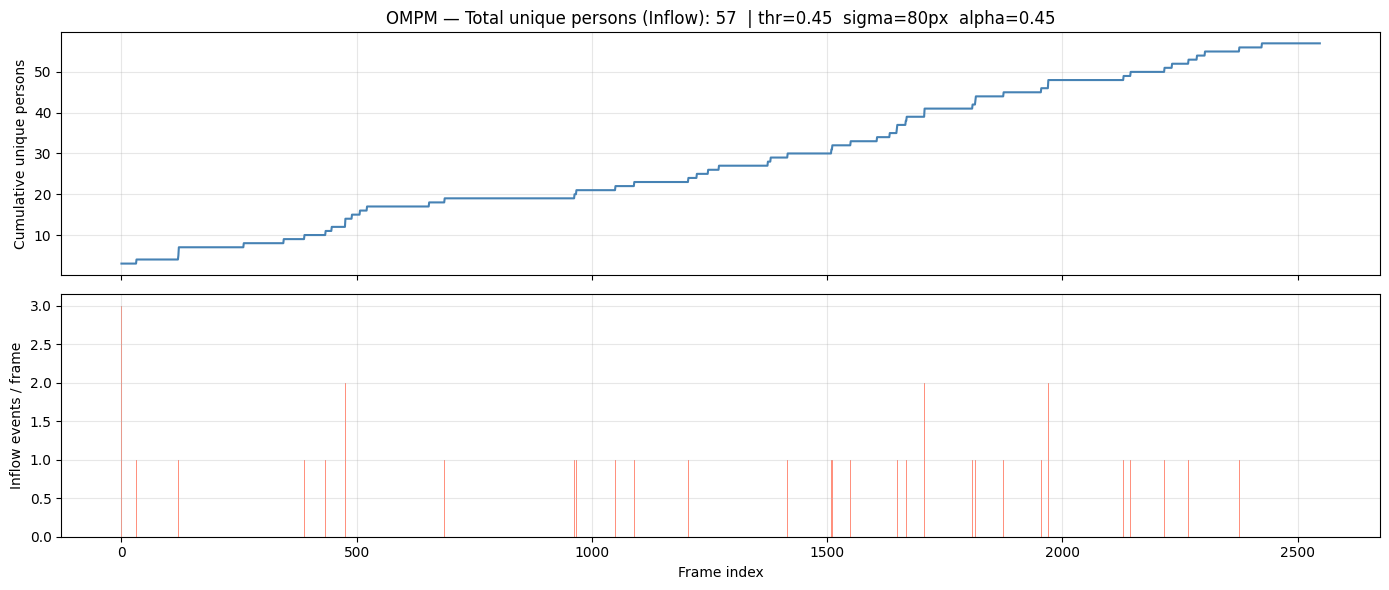

Saved: D:\เอกสาร\Connected\output\frames\ompm_inflow_timeline.png


In [36]:
import matplotlib.pyplot as plt

# Cumulative inflow over time
sorted_fis  = sorted(ompm_results.keys())
cumulative  = []
running_cnt = 0
for fi in sorted_fis:
    running_cnt += sum(1 for r in ompm_results[fi] if r['label'] == 'Inflow')
    cumulative.append(running_cnt)

# Per-frame inflow events
per_frame_in = [sum(1 for r in ompm_results[fi] if r['label'] == 'Inflow')
                for fi in sorted_fis]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(sorted_fis, cumulative, color='steelblue', linewidth=1.5)
ax1.set_ylabel('Cumulative unique persons')
ax1.set_title(f'OMPM — Total unique persons (Inflow): {inflow_count}  '
              f'| thr={OMPM_MATCH_THR}  sigma={OMPM_SIGMA}px  alpha={OMPM_ALPHA}')
ax1.grid(True, alpha=0.3)

ax2.bar(sorted_fis, per_frame_in, width=1, color='tomato', alpha=0.7)
ax2.set_ylabel('Inflow events / frame')
ax2.set_xlabel('Frame index')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
out_png = DIR_FRAMES / 'ompm_inflow_timeline.png'
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')


In [39]:
VID_OMPM_OUT   = DIR_VIDEOS / 'ompm_tracking.mp4'
TRAIL_LEN      = 45
MAIN_W, MAIN_H = 1280, 720

def uid_color(uid):
    np.random.seed(uid * 2654435761 % (2**32))
    h = np.random.randint(0, 180)
    return tuple(int(x) for x in
                 cv2.cvtColor(np.uint8([[[h, 210, 255]]]), cv2.COLOR_HSV2BGR)[0, 0])


cap_r   = cv2.VideoCapture(str(VIDEO_IN))
fps_in  = cap_r.get(cv2.CAP_PROP_FPS)
total_r = int(cap_r.get(cv2.CAP_PROP_FRAME_COUNT))
sx      = MAIN_W / cap_r.get(cv2.CAP_PROP_FRAME_WIDTH)
sy      = MAIN_H / cap_r.get(cv2.CAP_PROP_FRAME_HEIGHT)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
SLOW_FACTOR = 2   # 4x slower (29.9 fps -> ~7.5 fps)
writer = cv2.VideoWriter(str(VID_OMPM_OUT), fourcc, fps_in / SLOW_FACTOR, (MAIN_W, MAIN_H))

trail: dict[int, deque] = {}
running_inflow = 0

t0 = time.perf_counter()
fi = 0

while cap_r.isOpened():
    ret, bgr = cap_r.read()
    if not ret:
        break

    frame = cv2.resize(bgr, (MAIN_W, MAIN_H))

    if fi in ompm_results:
        rows = ompm_results[fi]
        running_inflow += sum(1 for r in rows if r['label'] == 'Inflow')

        # Update & draw trails
        for r in rows:
            uid = r['uid']
            px  = int(r['pos'][0] * sx)
            py  = int(r['pos'][1] * sy)
            if uid not in trail:
                trail[uid] = deque(maxlen=TRAIL_LEN)
            trail[uid].append((px, py))

        active_uids = {r['uid'] for r in rows}
        for uid, pts in trail.items():
            if uid not in active_uids:
                continue
            col = uid_color(uid)
            pt_list = list(pts)
            for k in range(1, len(pt_list)):
                alpha = k / len(pt_list)
                c = tuple(int(x * alpha) for x in col)
                cv2.line(frame, pt_list[k - 1], pt_list[k], c, 2, cv2.LINE_AA)

        # Draw persons
        for r in rows:
            uid    = r['uid']
            px     = int(r['pos'][0] * sx)
            py     = int(r['pos'][1] * sy)
            col    = uid_color(uid)
            is_new = r['label'] == 'Inflow'

            cv2.circle(frame, (px, py), 12, col, -1)
            cv2.circle(frame, (px, py), 12, (255, 255, 255), 1)

            if is_new:
                # Red ring + 'IN' marker for Inflow
                cv2.circle(frame, (px, py), 18, (0, 0, 255), 2)
                cv2.putText(frame, 'IN', (px - 8, py + 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 255), 2, cv2.LINE_AA)
            else:
                cv2.putText(frame, 'P', (px - 6, py + 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

            label_txt = f'#{uid}  {r["best_score"]:.2f}'
            cv2.putText(frame, label_txt, (px + 15, py - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)

        # HUD
        n_ped = sum(1 for r in rows if r['label'] == 'Pedestrian')
        n_in  = sum(1 for r in rows if r['label'] == 'Inflow')
        cv2.putText(frame, f'Frame {fi:4d}  P:{n_ped}  IN:{n_in}',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2, cv2.LINE_AA)
        cv2.putText(frame, f'Total unique persons (Inflow): {running_inflow}',
                    (10, 55), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 128), 2, cv2.LINE_AA)
        cv2.putText(frame,
                    f'thr={OMPM_MATCH_THR}  sigma={OMPM_SIGMA}px  memory={OMPM_MEMORY}f  max_age={OMPM_MAX_AGE}f',
                    (10, 76), cv2.FONT_HERSHEY_SIMPLEX, 0.43, (180, 180, 180), 1)

    writer.write(frame)
    fi += 1
    if fi % 500 == 0:
        elapsed = time.perf_counter() - t0
        eta     = elapsed / fi * (total_r - fi)
        print(f'  {fi}/{total_r} ({fi / total_r * 100:.0f}%)  ETA {eta:.0f}s')

cap_r.release()
writer.release()

elapsed = time.perf_counter() - t0
size_mb = VID_OMPM_OUT.stat().st_size / 1024**2
print(f'Done in {elapsed:.0f}s')
print(f'Saved: {VID_OMPM_OUT}  ({size_mb:.1f} MB)')
print(f'Final unique person count: {running_inflow}')


  500/2556 (20%)  ETA 42s
  1000/2556 (39%)  ETA 31s
  1500/2556 (59%)  ETA 21s
  2000/2556 (78%)  ETA 11s
  2500/2556 (98%)  ETA 1s
Done in 51s
Saved: D:\เอกสาร\Connected\output\videos\ompm_tracking.mp4  (152.9 MB)
Final unique person count: 57
